# **Modelo de MSGARCH**

In [ ]:
# 1. Instalar y cargar librerías necesarias
# if(!require(MSGARCH)) install.packages("MSGARCH")
# if(!require(quantmod)) install.packages("quantmod")

Observaciones: 1683 | 2020-01-03 a 2026-09-15

===== RESUMEN DEL AJUSTE =====
Specification type: Markov-switching
Specification name: sGARCH_norm sGARCH_norm
Number of parameters in each variance model: 3 3
Number of parameters in each distribution: 0 0
------------------------------------------
Fixed parameters:
None
------------------------------------------
Across regime constrained parameters:
None
------------------------------------------
Fitted parameters:
         Estimate Std. Error  t value  Pr(>|t|)
alpha0_1   4.7848     3.8025   1.2583 1.041e-01
alpha1_1   0.0393     0.0476   0.8246 2.048e-01
beta_1     0.0198     0.7477   0.0265 4.894e-01
alpha0_2   4.3177     2.6753   1.6139 5.327e-02
alpha1_2   0.0364     0.0389   0.9369 1.744e-01
beta_2     0.7429     0.1402   5.2998 5.795e-08
P_1_1      0.9866     0.0082 120.3446    <1e-16
P_2_1      0.0225     0.0050   4.5047 3.323e-06
------------------------------------------
Transition matrix:
      t+1|k=1 t+1|k=2
t|k=1  0.9866  

pdf 
  2


✔ Gráfico guardado en: ./outputs/NVDA_msgarch_regimenes.png
✔ Histórico guardado en: ./outputs/NVDA_msgarch_historico.csv (1683 filas)
✔ Listo.


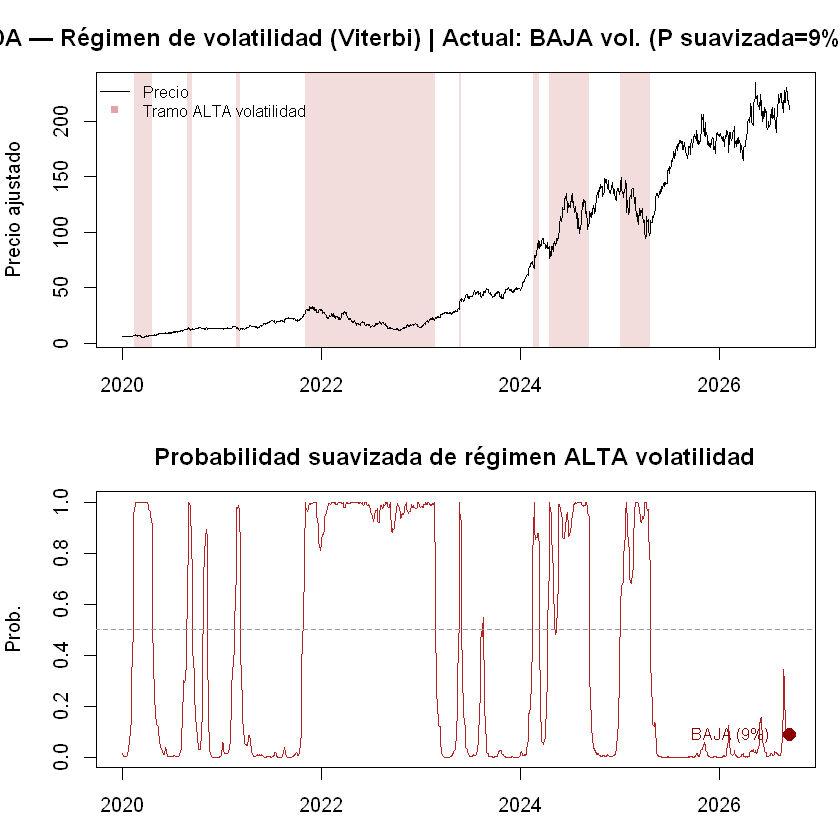

In [17]:
# ============================================================
# MS-GARCH(1,1) con K regímenes de volatilidad
# Identifica régimen ALTA/BAJA vol., resume la historia y
# reporta en qué régimen estamos hoy
# ============================================================

suppressPackageStartupMessages({
  library(quantmod)
  library(MSGARCH)
  library(xts)
})

# ---------- 0. CONFIG ----------
CONFIG <- list(
  ticker       = "NVDA",
  fecha_ini    = "2020-01-01",
  fecha_fin    = Sys.Date(),
  K            = 2,               # número de regímenes
  variance     = "sGARCH",
  distribucion = "norm",
  seed         = 123,
  out_dir      = "./outputs"
)

if (CONFIG$K != 2) {
  stop("Este script asume K = 2 (etiquetas BAJA/ALTA). Ajusta la lógica de identificación si usas más regímenes.")
}

dir.create(CONFIG$out_dir, showWarnings = FALSE, recursive = TRUE)
set.seed(CONFIG$seed)

# ---------- 1. Datos ----------
precios_raw <- tryCatch(
  getSymbols(CONFIG$ticker, src = "yahoo",
             from = CONFIG$fecha_ini, to = CONFIG$fecha_fin,
             auto.assign = FALSE),
  error = function(e) stop(sprintf("No se pudo descargar %s: %s", CONFIG$ticker, e$message))
)

precio <- na.omit(Ad(precios_raw))
ret <- na.omit(diff(log(precio)) * 100)
colnames(ret) <- "ret"

if (nrow(ret) < 500) {
  warning("Muestra pequeña (<500 obs.): los parámetros MS-GARCH pueden ser inestables.")
}

cat(sprintf("Observaciones: %d | %s a %s\n", nrow(ret),
            format(start(ret), "%Y-%m-%d"), format(end(ret), "%Y-%m-%d")))

# ---------- 2. Especificación MS-GARCH(1,1), K regímenes ----------
especificacion <- CreateSpec(
  variance.spec     = list(model = CONFIG$variance),
  distribution.spec = list(distribution = CONFIG$distribucion),
  switch.spec       = list(do.mix = FALSE, K = CONFIG$K)
)

# ---------- 3. Ajuste por Máxima Verosimilitud ----------
fit <- FitML(spec = especificacion, data = ret)

cat("\n===== RESUMEN DEL AJUSTE =====\n")
print(summary(fit))

# Matriz de transición y duración esperada por régimen (persistencia)
P <- TransMat(fit)
duracion_esperada <- 1 / (1 - diag(P))
cat("\nMatriz de transición (fila = régimen actual, col = régimen siguiente):\n")
print(round(P, 4))
cat("\nDuración esperada por régimen (en días hábiles, 1/(1-p_ii)):\n")
print(round(duracion_esperada, 1))

# ---------- 4. Identificar régimen de BAJA vs ALTA volatilidad ----------
# Se usa la volatilidad incondicional de cada régimen extraído del fit
# (más directo y estable que promediar la vol. condicional ponderada por prob.)
vol_incond <- sapply(ExtractStateFit(fit), UncVol)
reg_baja <- which.min(vol_incond)
reg_alta <- which.max(vol_incond)

cat(sprintf("\nVol. incondicional — Régimen 1: %.3f%% | Régimen 2: %.3f%%\n",
            vol_incond[1], vol_incond[2]))
cat(sprintf("→ Régimen BAJA volatilidad = %d (vol. incond. %.3f%%)\n", reg_baja, vol_incond[reg_baja]))
cat(sprintf("→ Régimen ALTA volatilidad = %d (vol. incond. %.3f%%)\n", reg_alta, vol_incond[reg_alta]))

# ---------- 5. Probabilidades y decodificación de estados ----------
estado <- State(fit)   # FiltProb, PredProb, SmoothProb, Viterbi

n <- nrow(ret)
fechas <- index(ret)

p_filt_alta   <- as.numeric(estado$FiltProb[, 1, reg_alta])          # T obs
p_smooth_alta <- as.numeric(estado$SmoothProb[2:(n + 1), 1, reg_alta]) # SmoothProb tiene T+1 filas; se alinea con `ret`
viterbi_raw   <- as.numeric(estado$Viterbi[, 1])                      # secuencia de régimen más probable (decodificada)
regimen_viterbi <- ifelse(viterbi_raw == reg_alta, "ALTA", "BAJA")     # etiqueta por día, para el CSV histórico
vol_cond      <- as.numeric(Volatility(fit))

# ---------- 6. Estado actual ----------
ultimo_regimen_viterbi  <- ifelse(tail(viterbi_raw, 1) == reg_alta, "ALTA", "BAJA")
ultima_prob_filt_alta   <- tail(p_filt_alta, 1)
ultima_prob_smooth_alta <- tail(p_smooth_alta, 1)

# Racha: cuántos días consecutivos lleva en el régimen actual (según Viterbi)
racha <- 1L
i <- length(viterbi_raw)
while (i > 1 && viterbi_raw[i] == viterbi_raw[i - 1]) { racha <- racha + 1L; i <- i - 1L }

pct_alta_hist <- mean(viterbi_raw == reg_alta) * 100

cat("\n===== ESTADO ACTUAL =====\n")
cat(sprintf("Fecha:                        %s\n", format(tail(fechas, 1), "%Y-%m-%d")))
cat(sprintf("Régimen (Viterbi):            %s volatilidad\n", ultimo_regimen_viterbi))
cat(sprintf("P(ALTA vol.) filtrada:        %.1f%%\n", 100 * ultima_prob_filt_alta))
cat(sprintf("P(ALTA vol.) suavizada:       %.1f%%\n", 100 * ultima_prob_smooth_alta))
cat(sprintf("Días consecutivos en régimen: %d\n", racha))
cat(sprintf("%% histórico en ALTA vol.:     %.1f%%\n", pct_alta_hist))
cat(sprintf("%% histórico en BAJA vol.:     %.1f%%\n", 100 - pct_alta_hist))

# ---------- 7. Gráfico final: resumen histórico + estado actual ----------
graficar <- function() {
  op <- par(no.readonly = TRUE)
  on.exit(par(op), add = TRUE)
  par(mfrow = c(2, 1), mar = c(3, 4, 3, 1))

  precio_alineado <- as.numeric(precio)[-1]  # quita la 1a obs. para alinear con `ret`/`fechas`

  # --- Panel 1: precio con sombreado del régimen decodificado (Viterbi) ---
  plot(fechas, precio_alineado, type = "n",
       main = sprintf("%s — Régimen de volatilidad (Viterbi) | Actual: %s vol. (P suavizada=%.0f%%, %d días)",
                       CONFIG$ticker, ultimo_regimen_viterbi, 100 * ultima_prob_smooth_alta, racha),
       ylab = "Precio ajustado", xlab = "")

  runs <- rle(viterbi_raw)
  idx_fin <- cumsum(runs$lengths)
  idx_ini <- c(1, head(idx_fin, -1) + 1)
  for (k in seq_along(runs$lengths)) {
    if (runs$values[k] == reg_alta) {
      rect(fechas[idx_ini[k]], par("usr")[3], fechas[idx_fin[k]], par("usr")[4],
           col = adjustcolor("firebrick", alpha.f = 0.15), border = NA)
    }
  }
  lines(fechas, precio_alineado, col = "black", lwd = 1)
  legend("topleft", legend = c("Precio", "Tramo ALTA volatilidad"),
         col = c("black", adjustcolor("firebrick", alpha.f = 0.4)),
         lty = c(1, NA), pch = c(NA, 15), bty = "n", cex = 0.8)

  # --- Panel 2: probabilidad suavizada de régimen ALTA + punto actual ---
  plot(fechas, p_smooth_alta, type = "l", col = "firebrick", lwd = 1.2, ylim = c(0, 1),
       main = "Probabilidad suavizada de régimen ALTA volatilidad",
       ylab = "Prob.", xlab = "")
  abline(h = 0.5, col = "gray60", lty = 2)
  points(tail(fechas, 1), ultima_prob_smooth_alta, pch = 19, col = "darkred", cex = 1.4)
  # pos = 2 (a la izquierda del punto): el último punto es el borde derecho del
  # gráfico, así que una etiqueta a la derecha (pos = 4) queda cortada por el margen
  text(tail(fechas, 1), ultima_prob_smooth_alta,
       labels = sprintf("%s (%.0f%%)  ", ultimo_regimen_viterbi, 100 * ultima_prob_smooth_alta),
       pos = 2, cex = 0.8, col = "darkred", xpd = NA)
}

# Mostrar en pantalla
graficar()

# Guardar copia en ./outputs/
png_path <- file.path(CONFIG$out_dir, sprintf("%s_msgarch_regimenes.png", CONFIG$ticker))
png(png_path, width = 1200, height = 900, res = 130)
graficar()
dev.off()

cat(sprintf("\n✔ Gráfico guardado en: %s\n", png_path))

# ---------- 8. CSV con el histórico completo analizado por el modelo ----------
historico <- data.frame(
  fecha                  = format(fechas, "%Y-%m-%d"),
  retorno_pct            = as.numeric(ret),
  vol_condicional_pct    = vol_cond,
  prob_filtrada_alta     = p_filt_alta,
  prob_suavizada_alta    = p_smooth_alta,
  regimen_viterbi        = regimen_viterbi,
  stringsAsFactors       = FALSE
)

csv_path <- file.path(CONFIG$out_dir, sprintf("%s_msgarch_historico.csv", CONFIG$ticker))
write.csv(historico, csv_path, row.names = FALSE)
cat(sprintf("✔ Histórico guardado en: %s (%d filas)\n", csv_path, nrow(historico)))

cat("✔ Listo.\n")